In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# Cargar el dataset real
df = pd.read_csv("ad_viz_plotval_data 2023.csv")
df.head()  # Vemos los 5 primeros datos en el data frame


,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,20200018,1,1.3,ppm,15,GARDEN/TRINITY CHRISTIAN CHURCH,18,75.0,...,Carbon monoxide,554,11260,"Anchorage, AK",2,Alaska,20,Anchorage,61.205861,-149.824602
1,01/02/2023,AQS,20200018,1,1.3,ppm,15,GARDEN/TRINITY CHRISTIAN CHURCH,24,100.0,...,Carbon monoxide,554,11260,"Anchorage, AK",2,Alaska,20,Anchorage,61.205861,-149.824602
2,01/03/2023,AQS,20200018,1,1.7,ppm,19,GARDEN/TRINITY CHRISTIAN CHURCH,24,100.0,...,Carbon monoxide,554,11260,"Anchorage, AK",2,Alaska,20,Anchorage,61.205861,-149.824602
3,01/04/2023,AQS,20200018,1,1.0,ppm,11,GARDEN/TRINITY CHRISTIAN CHURCH,24,100.0,...,Carbon monoxide,554,11260,"Anchorage, AK",2,Alaska,20,Anchorage,61.205861,-149.824602
4,01/05/2023,AQS,20200018,1,1.5,ppm,17,GARDEN/TRINITY CHRISTIAN CHURCH,24,100.0,...,Carbon monoxide,554,11260,"Anchorage, AK",2,Alaska,20,Anchorage,61.205861,-149.824602


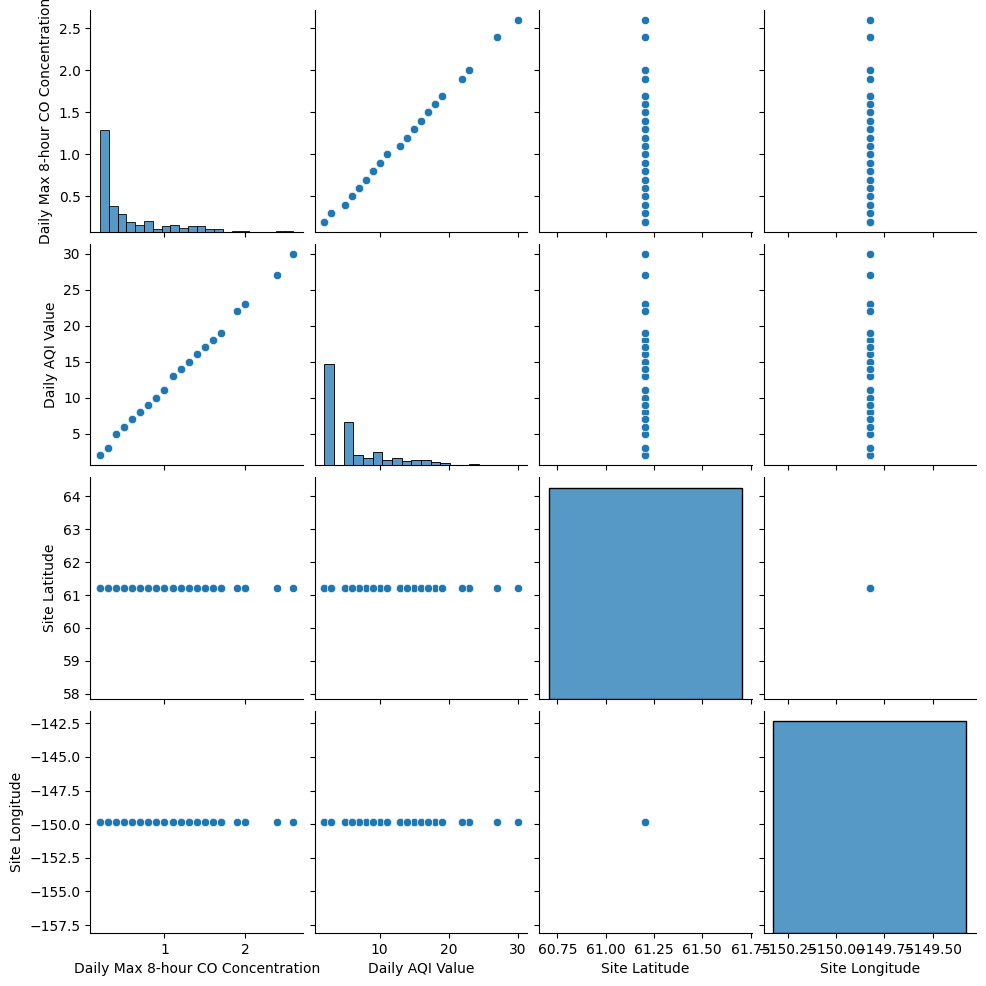

In [27]:
# Función que muestra las relaciones entre todas las variables numéricas
sns.pairplot(df[["Daily Max 8-hour CO Concentration", "Daily AQI Value", "Site Latitude", "Site Longitude"]])
plt.show()


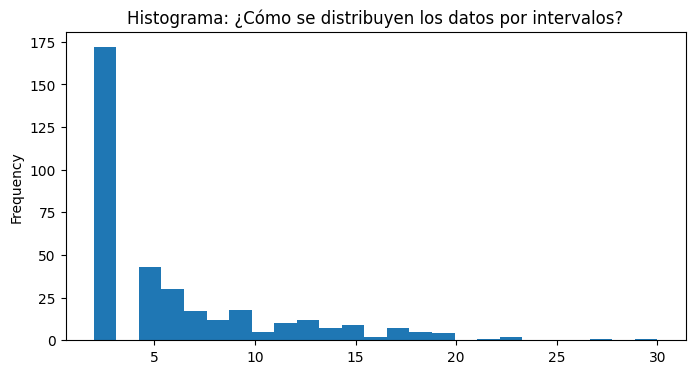

In [7]:
# Histograma en 25 intervalos para la variable objetivo
df["Daily AQI Value"].plot.hist(bins=25, figsize=(8, 4))
plt.title("Histograma: ¿Cómo se distribuyen los datos por intervalos?")
plt.show()

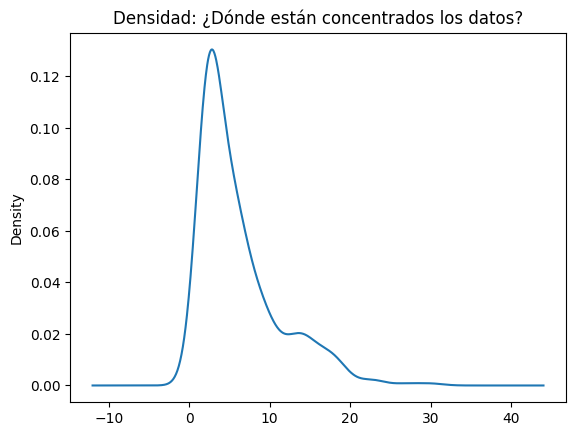

In [8]:
# Gráfico de densidad
df["Daily AQI Value"].plot.density()
plt.title("Densidad: ¿Dónde están concentrados los datos?")
plt.show()

In [29]:
numeric_df = df.select_dtypes(include=[np.number])


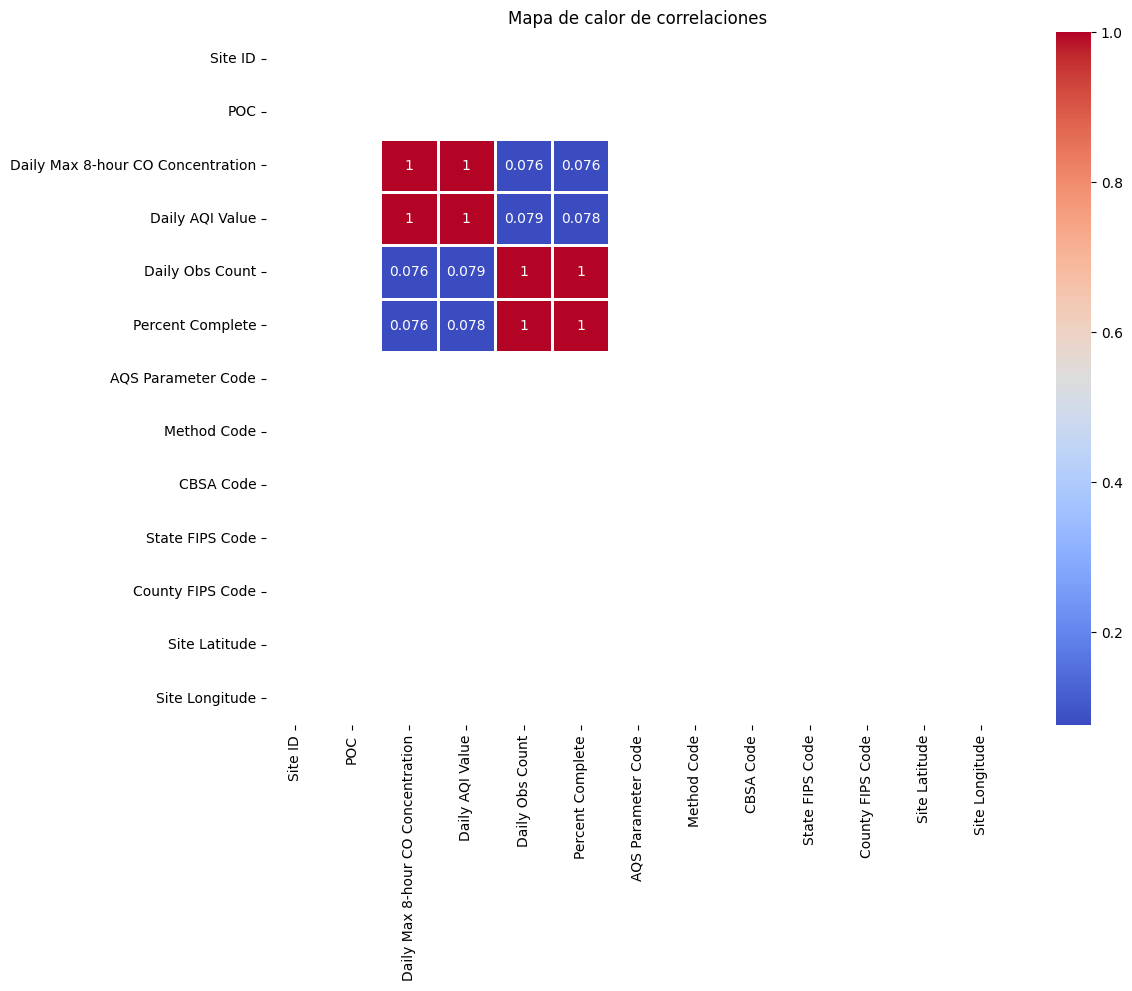

In [10]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2, cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")
plt.show()

In [11]:
# Definimos X con las 4 variables predictoras numéricas y Y como el objetivo continuo
X = df[
    [
        "Daily Max 8-hour CO Concentration",
        "Site Latitude",
        "Site Longitude",
        "Daily Obs Count",
    ]
]
Y = df["Daily AQI Value"]

from sklearn.model_selection import train_test_split

# Dividimos en 70% entrenamiento y 30% prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=123
)


In [12]:
from sklearn import metrics
from sklearn.linear_model import LinearRegression

lm = LinearRegression()  # Creando un objeto de Regresión Lineal 'lm'
lm.fit(X_train, Y_train)

print("El término de intersección del modelo lineal: ", lm.intercept_)
print("Los coeficientes del modelo lineal:", lm.coef_)


El término de intersección del modelo lineal:  -0.29691696712963545
Los coeficientes del modelo lineal: [ 1.16189698e+01  0.00000000e+00 -1.66126622e-31  3.48437922e-03]


In [13]:
# DataFrame base para los coeficientes
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])

# Cálculo manual del Error Estándar y Estadístico t
n = X_train.shape[0]  # Número de observaciones usadas para entrenar
k = X_train.shape[1]  # Número de variables predictoras: 4
dfN = n - k  # Cálculo de los grados de libertad
train_pred = lm.predict(X_train)  # Generamos las predicciones del modelo

train_error = np.square(train_pred - Y_train)
sum_error = np.sum(train_error)

se = [0, 0, 0, 0]
for i in range(k):
    r = sum_error / dfN
    r = r / np.sum(
        np.square(
            X_train[list(X_train.columns)[i]]
            - X_train[list(X_train.columns)[i]].mean()
        )
    )
    se[i] = np.sqrt(r)  # Obtenemos el error estándar de cada coeficiente

cdf["Standard Error"] = se
cdf["t_statistic"] = cdf["Coefficients"] / cdf["Standard Error"]

cdf


/tmp/ipykernel_602/1330675188.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  r = r / np.sum(


,Coefficients,Standard Error,t_statistic
Daily Max 8-hour CO Concentration,1.161897e+01,4.778780e-02,2.431368e+02
Site Latitude,0.000000e+00,inf,0.000000e+00
Site Longitude,-1.661266e-31,6.875523e+11,-2.416203e-43
Daily Obs Count,3.484379e-03,5.509084e-03,6.324788e-01


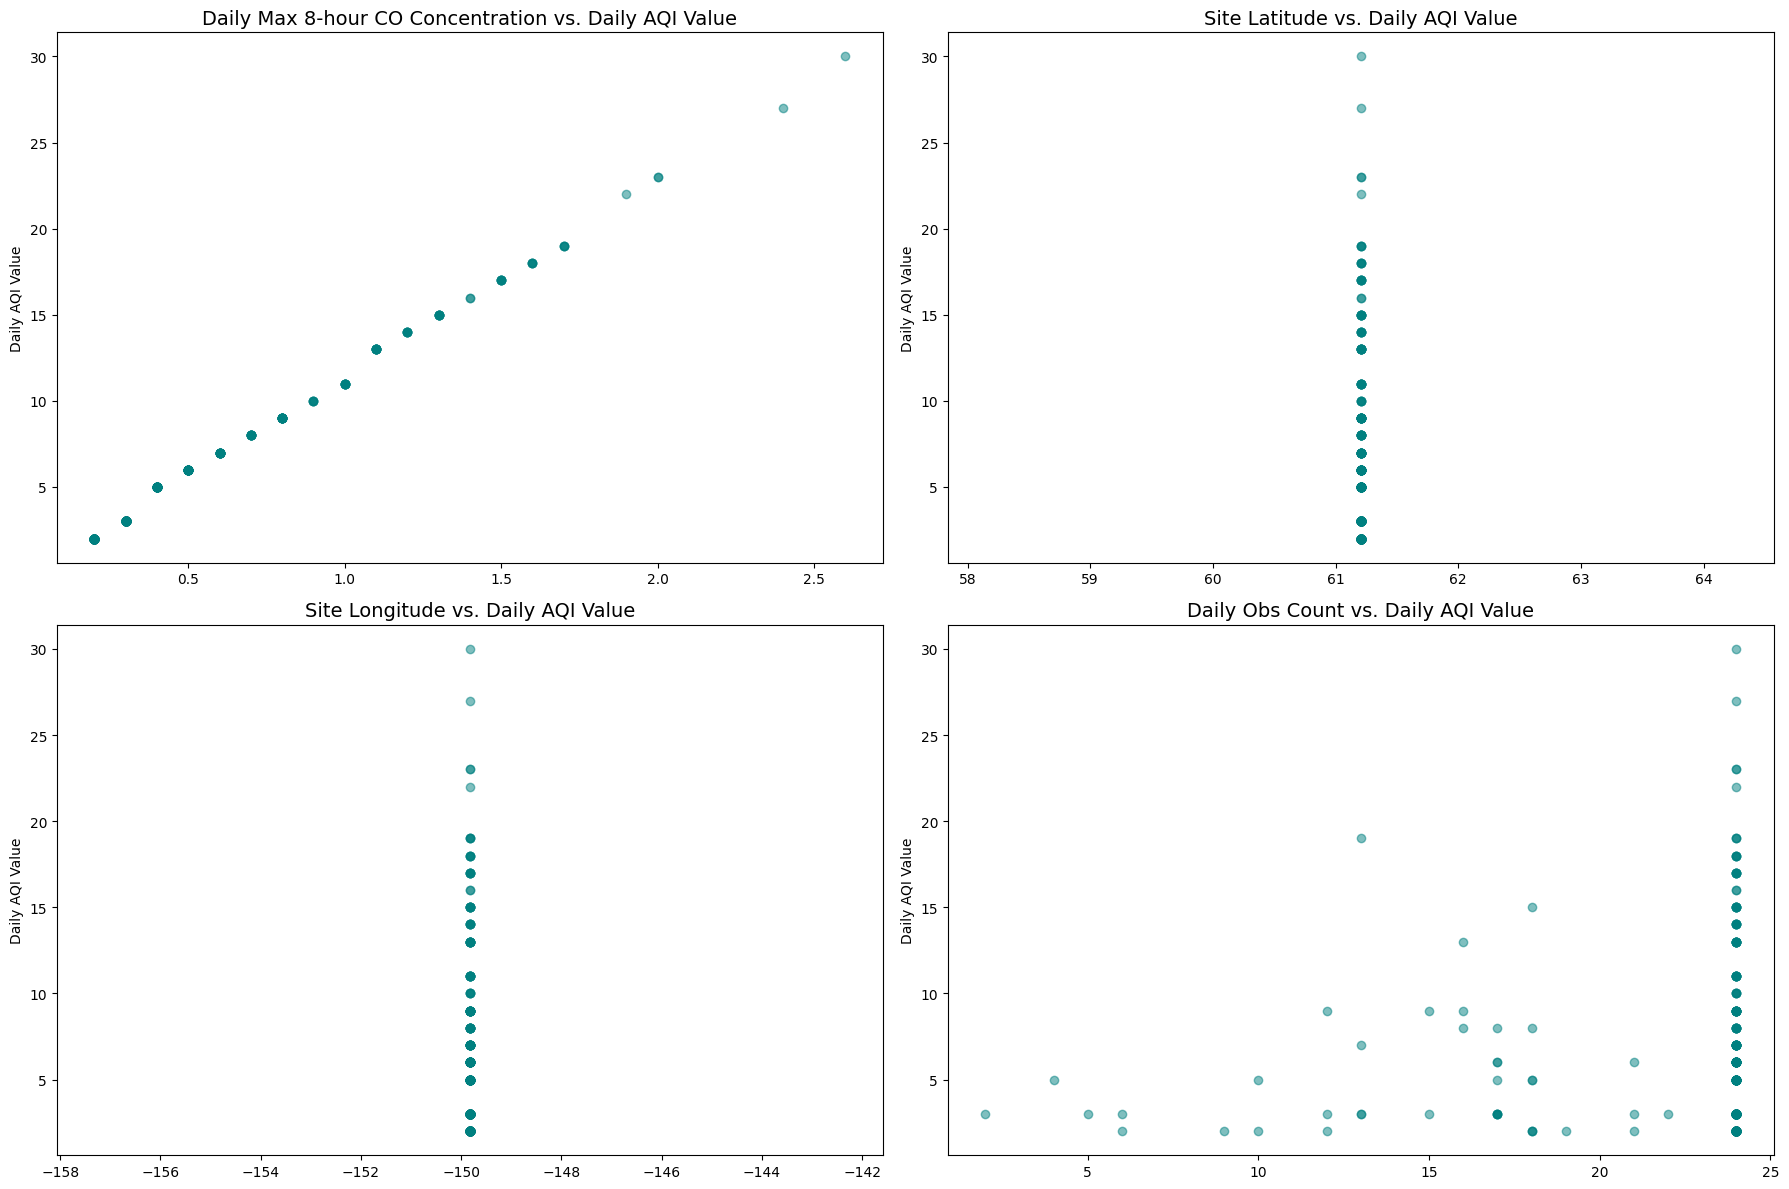

In [14]:
from matplotlib import gridspec

l = list(cdf.index)

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2)

# Mapeo dinámico automatizado usando las variables de tus datos reales
for i in range(4):
    ax = plt.subplot(gs[i])
    ax.scatter(df[l[i]], df["Daily AQI Value"], alpha=0.5, c="teal")
    ax.set_title(f"{l[i]} vs. Daily AQI Value", fontdict={"fontsize": 14})
    ax.set_ylabel("Daily AQI Value")

plt.tight_layout()
plt.show()


In [26]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)



Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (108,)


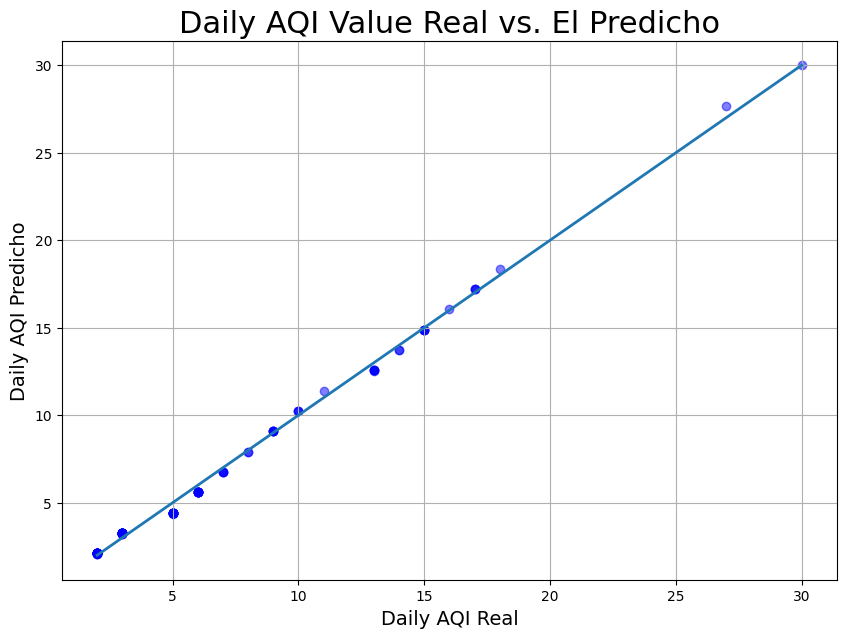

In [23]:
# Diagrama de dispersión: Real vs Predicho
plt.figure(figsize=(10, 7))
plt.scatter(Y_test, predictions, alpha=0.5, color="blue")
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    lw=2,
)
plt.title("Daily AQI Value Real vs. El Predicho", fontsize=22)
plt.xlabel("Daily AQI Real", fontsize=14)
plt.ylabel("Daily AQI Predicho", fontsize=14)
plt.grid(True)
plt.show()



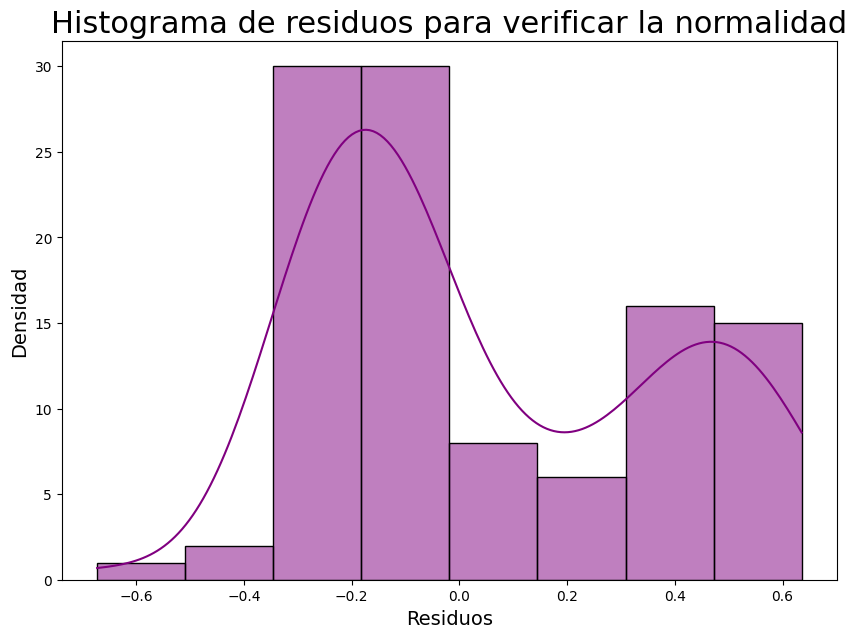

In [17]:
# Histograma de residuos (Actualizado de sns.distplot a sns.histplot con KDE)
plt.figure(figsize=(10, 7))
sns.histplot((Y_test - predictions), kde=True, color="purple")
plt.title("Histograma de residuos para verificar la normalidad", fontsize=22)
plt.xlabel("Residuos", fontsize=14)
plt.ylabel("Densidad", fontsize=14)
plt.show()



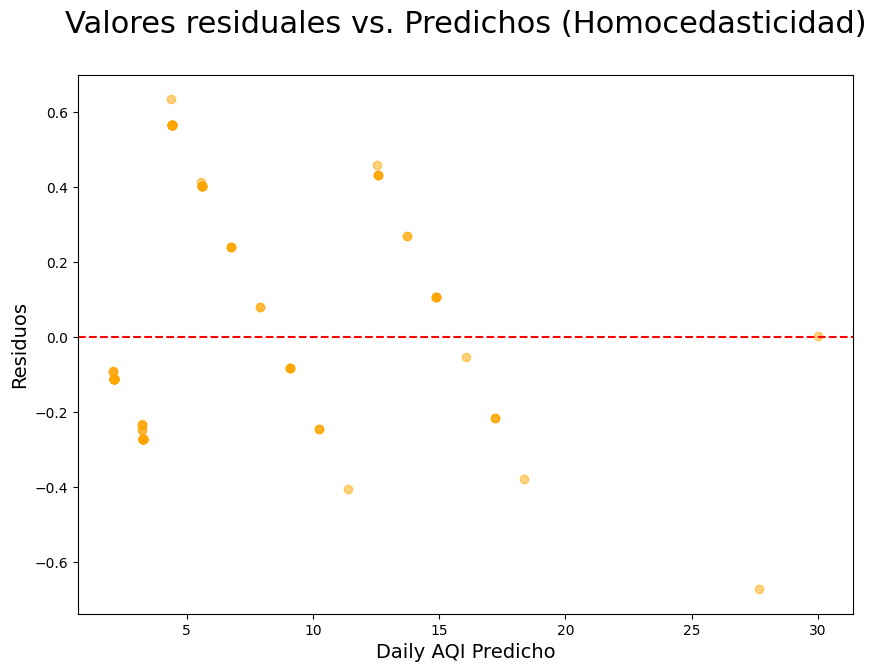

In [18]:
# Diagrama de dispersión (Homocedasticidad)
plt.figure(figsize=(10, 7))
plt.scatter(x=predictions, y=Y_test - predictions, alpha=0.5, color="orange")
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Valores residuales vs. Predichos (Homocedasticidad)\n", fontsize=22)
plt.xlabel("Daily AQI Predicho", fontsize=14)
plt.ylabel("Residuos", fontsize=14)
plt.show()


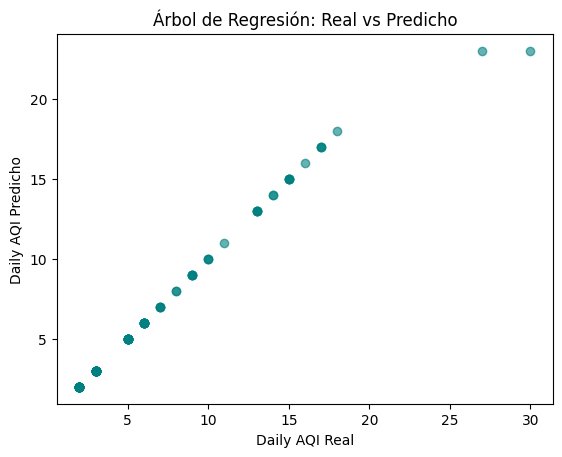

Mean square error (MSE): 0.6018518518518519


In [31]:
# 1. Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
#                                        niveles de decisión
tree_model.fit(X_train, Y_train)  # Entrenamos con los datos del CSV

from sklearn import metrics

# 2. Hacemos predicciones
test_pred = tree_model.predict(X_test)

# 3. Gráfico de dispersión (Real vs Predicho)
plt.scatter(x=Y_test, y=test_pred, color="teal", alpha=0.6)  # real vs dicho
plt.xlabel("Daily AQI Real")
plt.ylabel("Daily AQI Predicho")
plt.title("Árbol de Regresión: Real vs Predicho")
plt.show()

# 4. Cálculo del Error Cuadrático Medio
print("Mean square error (MSE):", metrics.mean_squared_error(Y_test, test_pred))


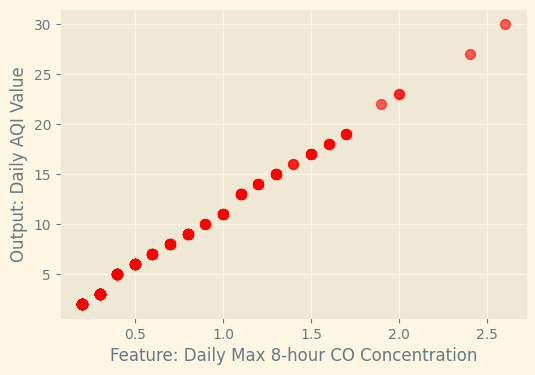

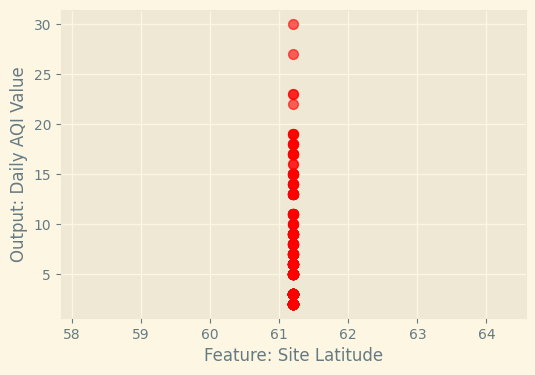

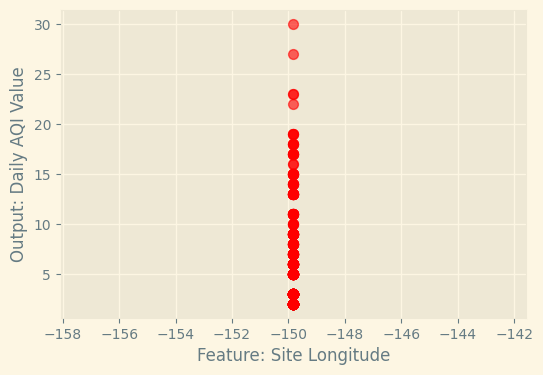

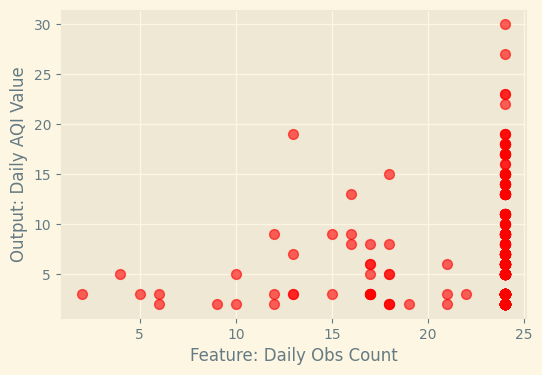

In [30]:
# Gráficos individuales con fondo Solarize_Light2 para tus variables reales
with plt.style.context(('Solarize_Light2')):
    for col in X.columns:
        plt.figure(figsize=(6,4))
        plt.grid(True)
        plt.xlabel('Feature: ' + col, fontsize=12)
        plt.ylabel('Output: Daily AQI Value', fontsize=12)
        plt.scatter(X[col], Y, c='red', s=50, alpha=0.6)
        plt.show()


Mean square error (MSE): 0.6018518518518519
Importancia relativa de las características:  [1. 0. 0. 0.]


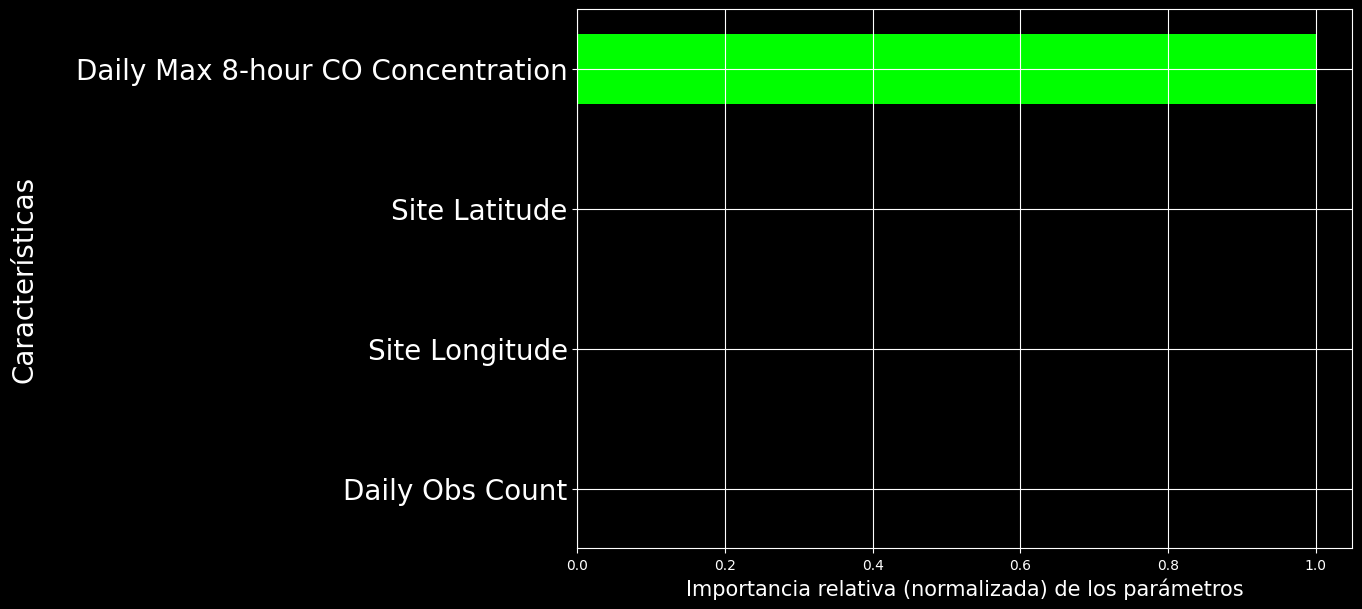

In [24]:
from sklearn import tree

tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
tree_model.fit(X_train, Y_train)
test_pred = tree_model.predict(X_test)

print("Mean square error (MSE):", metrics.mean_squared_error(Y_test, test_pred))
print("Importancia relativa de las características: ", tree_model.feature_importances_)

# Gráfico con el estilo original Dark Background
with plt.style.context("dark_background"):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(4, 0, -1), X.columns, fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(
        range(4, 0, -1), width=tree_model.feature_importances_, height=0.5, color="lime"
    )
    plt.show()


In [21]:
import statsmodels.api as sm

# Resumen completo OLS para evaluar p-values de tus variables reales
Xs = sm.add_constant(X)
stat_model = sm.OLS(Y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())


                            OLS Regression Results                            
Dep. Variable:        Daily AQI Value   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 4.503e+04
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:34:33   Log-Likelihood:                -89.698
No. Observations:                 358   AIC:                             185.4
Df Residuals:                     355   BIC:                             197.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Daily 

/tmp/ipykernel_602/2564456899.py:6: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  stat_result = stat_model.fit()
